# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [65]:
import pandas as pd
import numpy as np # linear algebra
import matplotlib.pyplot as plt # data visualization
import plotly.express as px
import seaborn as sns # statistical data visualization
import category_encoders as ce

from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, precision_recall_curve, roc_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

In [35]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [36]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [38]:
# Calssify new data based of the features if the ne applicant
# can be granted a loan or not.In this excersize we train the data with different
# models and identify the model that best can predict the classification

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [39]:
# checking null values
print(df.isnull().sum())

col_names = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome','education']
for col in col_names:
    print(df[col].value_counts()) 
    print('====================')

# in feature 'default', the size of the unknown is large and its very unbalanced 
# in feature 'poutcome' , largest value is nonexistent 
# remove these two columns
df = df.drop(['default', 'poutcome'], axis=1)
print(df.info())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64
housing
yes        21576
no         18622
unknown      990
Name: count

In [40]:
# explore the target variable 
df['y'].value_counts()

# looking at the target count, the data is unbalenced and would
# be hard to use Accuracy to determin the best model, i would also look
# at the f1 score

y
no     36548
yes     4640
Name: count, dtype: int64

In [41]:
# encoding part
#i will use one OneHotEncoder for month and day_of_week, and category_encoders for rest
# reset column names
col_names = ['job', 'marital', 'housing', 'loan', 'contact', 'month', 'day_of_week']
ohe = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
ohetransform = ohe.fit_transform(df[['month', 'day_of_week']])

df_encoded = pd.concat([df, ohetransform], axis=1).drop(columns=['month', 'day_of_week'])

print(df_encoded.info())
print(df_encoded.head())


<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 32 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              41188 non-null  int64  
 1   job              41188 non-null  str    
 2   marital          41188 non-null  str    
 3   education        41188 non-null  str    
 4   housing          41188 non-null  str    
 5   loan             41188 non-null  str    
 6   contact          41188 non-null  str    
 7   duration         41188 non-null  int64  
 8   campaign         41188 non-null  int64  
 9   pdays            41188 non-null  int64  
 10  previous         41188 non-null  int64  
 11  emp.var.rate     41188 non-null  float64
 12  cons.price.idx   41188 non-null  float64
 13  cons.conf.idx    41188 non-null  float64
 14  euribor3m        41188 non-null  float64
 15  nr.employed      41188 non-null  float64
 16  y                41188 non-null  str    
 17  month_apr        41188 

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [42]:
X = df_encoded.drop(['y'], axis=1)
y = df_encoded['y'].map({'no': 0, 'yes': 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42,stratify=y)

In [43]:
# check the shape of X_train and X_test
print(X_train.shape, X_test.shape)

#check the balance in y 
print(y_train.value_counts())
print(y_test.value_counts())

(27595, 31) (13593, 31)
y
0    24486
1     3109
Name: count, dtype: int64
y
0    12062
1     1531
Name: count, dtype: int64


In [44]:

encoder = ce.OrdinalEncoder(cols=['job', 'marital', 'housing', 'loan', 'contact', 'education'])
X_train = encoder.fit_transform(X_train)
X_test = encoder.fit_transform(X_test)

print(X_test.info())
print(X_test.head())

<class 'pandas.DataFrame'>
Index: 13593 entries, 37083 to 32078
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              13593 non-null  int64  
 1   job              13593 non-null  int64  
 2   marital          13593 non-null  int64  
 3   education        13593 non-null  int64  
 4   housing          13593 non-null  int64  
 5   loan             13593 non-null  int64  
 6   contact          13593 non-null  int64  
 7   duration         13593 non-null  int64  
 8   campaign         13593 non-null  int64  
 9   pdays            13593 non-null  int64  
 10  previous         13593 non-null  int64  
 11  emp.var.rate     13593 non-null  float64
 12  cons.price.idx   13593 non-null  float64
 13  cons.conf.idx    13593 non-null  float64
 14  euribor3m        13593 non-null  float64
 15  nr.employed      13593 non-null  float64
 16  month_apr        13593 non-null  float64
 17  month_aug        13593 n

In [14]:
#for feature in df.columns.drop('y'):
 #   fig = px.scatter(df, x=feature, y='y', title=f'{feature} vs Target')
 #   fig.show()

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [47]:
dummy_clf = ''
baseline_score = ''

dummy_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('dummy_model', DummyClassifier(random_state=42))
])

param_grid = {
    'scaler__with_mean': [True, False], 
    'dummy_model__strategy': ['most_frequent', 'prior', 'stratified', 'uniform']
}

grid_search = GridSearchCV(estimator=dummy_pipe, 
                           param_grid=param_grid, 
                           cv=5, 
                           scoring='accuracy')

#print(X_train.head())
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")
print(f"Test Set Accuracy: {grid_search.score(X_test, y_test):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, grid_search.predict(X_test)):.4f}")
print(f"Train Accuracy: {accuracy_score(y_train, grid_search.predict(X_train)):.4f}")
print(f"Test Precision: {precision_score(y_test, grid_search.predict(X_test), pos_label=0):.4f}")
print(f"Test Recall: {recall_score(y_test, grid_search.predict(X_test), pos_label=0):.4f}")
print(f"Test f1: {f1_score(y_test, grid_search.predict(X_test), pos_label=0):.4f}")

Best Parameters: {'dummy_model__strategy': 'most_frequent', 'scaler__with_mean': True}
Best Cross-Validation Score: 0.8873
Test Set Accuracy: 0.8874
Test Accuracy: 0.8874
Train Accuracy: 0.8873
Test Precision: 0.8874
Test Recall: 1.0000
Test f1: 0.9403


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [49]:
logreg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42))
])

logreg = logreg_pipe.fit(X_train, y_train)
print(f"Test Accuracy: {accuracy_score(y_test, logreg.predict(X_test)):.4f}")
print(f"Train Accuracy: {accuracy_score(y_train, logreg.predict(X_train)):.4f}")

Test Accuracy: 0.9058
Train Accuracy: 0.9106


### Problem 9: Score the Model

What is the accuracy of your model?

In [2]:
#Test Accuracy: 0.9096
#Train Accuracy: 0.9109

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [105]:
# initialize dictionary to store model, results
results = {
    'Model':[],
    'Train Time':[],
    'Train Accuracy':[],
    'Test Accuracy':[],
    'Test Precision':[],
    'Test Recall':[],
    'Test f1':[]
}

# initialize dictionary for the models
models = {
    'KNN':KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM':SVC()
}

import time

for model_name, model in models.items():
    start_time = time.time()
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start_time
    pred = pipeline.predict(X_test)
    results['Model'].append(model_name)
    results['Train Time'].append(train_time)
    results['Train Accuracy'].append(accuracy_score(y_train, pipeline.predict(X_train)))
    results['Test Accuracy'].append(accuracy_score(y_test, pred))
    results['Test Precision'].append(precision_score(y_test, pred))
    results['Test Recall'].append(recall_score(y_test, pred))
    results['Test f1'].append(f1_score(y_test, pred))

In [106]:
# printing the default model setting comparison
print(pd.DataFrame(results))


                 Model  Train Time  Train Accuracy  Test Accuracy  \
0                  KNN    0.020845        0.924443       0.900905   
1        Decision Tree    0.131650        1.000000       0.880159   
2  Logistic Regression    0.042933        0.910600       0.905834   
3                  SVM    4.280630        0.923211       0.907820   

   Test Precision  Test Recall   Test f1  
0        0.601996     0.354670  0.446363  
1        0.467026     0.453298  0.460060  
2        0.667557     0.326584  0.438596  
3        0.685829     0.335075  0.450197  


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [53]:
# calculating the best knneighbors
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
    ])
knn_grid = GridSearchCV(knn_pipe, 
                        param_grid={'knn__n_neighbors': range(1, 50, 2)},
                        cv=5,  
                        scoring=['accuracy','roc_auc', 'f1'], 
                        n_jobs=-1, 
                        refit='roc_auc',
                        error_score="raise")
knn_grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__n_neighbors': range(1, 50, 2)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'roc_auc', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displa

In [54]:
print(knn_grid.best_params_)
print(f"knn Test Accuracy: {accuracy_score(y_test, knn_grid.predict(X_test)):.4f}")
print(f"knn Train Accuracy: {accuracy_score(y_train, knn_grid.predict(X_train)):.4f}")
print(f"knn Test Precision: {precision_score(y_test, knn_grid.predict(X_test), pos_label=0):.4f}")
print(f"knn Test Recall: {recall_score(y_test, knn_grid.predict(X_test), pos_label=0):.4f}")
print(f"knn Test f1: {f1_score(y_test, knn_grid.predict(X_test), pos_label=0):.4f}")

{'knn__n_neighbors': 49}
knn Test Accuracy: 0.9028
knn Train Accuracy: 0.9040
knn Test Precision: 0.9113
knn Test Recall: 0.9865
knn Test f1: 0.9474


In [55]:
logreg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=10000)) 
])

logreg_param_grid = [
    {
        'logreg__C': np.logspace(-4, 4, 20),
        'logreg__l1_ratio': [1],
        'logreg__solver': ['liblinear', 'saga'],
    },
    {
        'logreg__C': np.logspace(-4, 4, 20),
        'logreg__l1_ratio': [0],
        'logreg__solver': ['lbfgs', 'newton-cg', 'sag']
    },
    {
        'logreg__C': np.logspace(-4, 4, 20),
        'logreg__penalty': ['elasticnet'],
        'logreg__solver': ['saga'],
        'logreg__l1_ratio': [0.2, 0.5, 0.8]  # Required only for elasticnet
    }
]

logreg_grid = GridSearchCV(estimator=logreg_pipeline, 
                           param_grid=logreg_param_grid, 
                           cv=5, 
                           scoring=['accuracy','roc_auc', 'f1'], 
                           n_jobs=-1, 
                           refit='roc_auc',
                           error_score="raise")
logreg_grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...iter=10000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'logreg__C': array([1.0000...00000000e+04]), 'logreg__l1_ratio': [1], 'logreg__solver': ['liblinear', 'saga']}, {'logreg__C': array([1.0000...00000000e+04]), 'logreg__l1_ratio': [0], 'logreg__solver': ['lbfgs', 'newton-cg', ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'roc_auc', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold 

In [56]:
print(logreg_grid.best_params_)
print(f"LogisticRegression Test Accuracy: {accuracy_score(y_test, logreg_grid.predict(X_test)):.4f}")
print(f"LogisticRegression Train Accuracy: {accuracy_score(y_train, logreg_grid.predict(X_train)):.4f}")
print(f"LogisticRegression Test Precision: {precision_score(y_test, logreg_grid.predict(X_test), pos_label=0):.4f}")
print(f"LogisticRegression Test Recall: {recall_score(y_test, logreg_grid.predict(X_test), pos_label=0):.4f}")
print(f"LogisticRegression Test f1: {f1_score(y_test, logreg_grid.predict(X_test), pos_label=0):.4f}")

{'logreg__C': np.float64(4.281332398719396), 'logreg__l1_ratio': 0, 'logreg__solver': 'lbfgs'}
LogisticRegression Test Accuracy: 0.9057
LogisticRegression Train Accuracy: 0.9106
LogisticRegression Test Precision: 0.9194
LogisticRegression Test Recall: 0.9796
LogisticRegression Test f1: 0.9485


In [57]:
dtree_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('dtree', DecisionTreeClassifier(random_state=42)) 
])

dtree_param_grid = {
    'dtree__criterion': ['gini', 'entropy', 'log_loss'],
    'dtree__max_depth': [None, 3, 5, 7, 10],
    'dtree__min_samples_split': [2, 5, 10],
    'dtree__min_samples_leaf': [1, 2, 4],
    'dtree__max_features': [None, 'sqrt', 'log2']
}



dtree_grid = GridSearchCV(estimator=dtree_pipeline, 
                           param_grid=dtree_param_grid, 
                           cv=5, 
                           scoring=['accuracy','roc_auc', 'f1'], 
                           n_jobs=-1, 
                           refit='roc_auc',
                           error_score="raise")

dtree_grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'dtree__criterion': ['gini', 'entropy', ...], 'dtree__max_depth': [None, 3, ...], 'dtree__max_features': [None, 'sqrt', ...], 'dtree__min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'roc_auc', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the hi

In [58]:
print(dtree_grid.best_params_)
print(f"DTree Test Accuracy: {accuracy_score(y_test, dtree_grid.predict(X_test)):.4f}")
print(f"DTree Train Accuracy: {accuracy_score(y_train, dtree_grid.predict(X_train)):.4f}")
print(f"DTree Test Precision: {precision_score(y_test, dtree_grid.predict(X_test), pos_label=0):.4f}")
print(f"DTree Test Recall: {recall_score(y_test, dtree_grid.predict(X_test), pos_label=0):.4f}")
print(f"DTree Test f1: {f1_score(y_test, dtree_grid.predict(X_test), pos_label=0):.4f}")

{'dtree__criterion': 'entropy', 'dtree__max_depth': 5, 'dtree__max_features': None, 'dtree__min_samples_leaf': 1, 'dtree__min_samples_split': 2}
DTree Test Accuracy: 0.9086
DTree Train Accuracy: 0.9170
DTree Test Precision: 0.9326
DTree Test Recall: 0.9669
DTree Test f1: 0.9494


In [59]:
svce_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC()) 
])

svc_param_grid = [
    {
        'svc__C': [0.1, 1, 10, 100], 
        'svc__kernel': ['linear', 'poly']
    },
    {
        'svc__C': [0.1, 1, 10, 100], 
        'svc__gamma': [0.001, 0.01, 0.1, 1], 
        "svc__kernel": ['rbf', 'sigmoid']
    }
]

svc_grid = GridSearchCV(estimator=svce_pipeline, 
                           param_grid=svc_param_grid, 
                           cv=5, 
                           scoring=['accuracy','roc_auc', 'f1'], 
                           n_jobs=-1, 
                           refit='roc_auc',
                           error_score="raise")

svc_grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svc', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'svc__C': [0.1, 1, ...], 'svc__kernel': ['linear', 'poly']}, {'svc__C': [0.1, 1, ...], 'svc__gamma': [0.001, 0.01, ...], 'svc__kernel': ['rbf', 'sigmoid']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'roc_auc', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the m

In [60]:
print(svc_grid.best_params_)
print(f"SVC Test Accuracy: {accuracy_score(y_test, svc_grid.predict(X_test)):.4f}")
print(f"SVC Train Accuracy: {accuracy_score(y_train, svc_grid.predict(X_train)):.4f}")
print(f"SVC Test Precision: {precision_score(y_test, svc_grid.predict(X_test), pos_label=0):.4f}")
print(f"SVC Test Recall: {recall_score(y_test, svc_grid.predict(X_test), pos_label=0):.4f}")
print(f"SVC Test f1: {f1_score(y_test, svc_grid.predict(X_test), pos_label=0):.4f}")

{'svc__C': 1, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
SVC Test Accuracy: 0.9083
SVC Train Accuracy: 0.9135
SVC Test Precision: 0.9199
SVC Test Recall: 0.9821
SVC Test f1: 0.9500


In [98]:

final_results = {
    'Model':[],
    'Train Time':[],
    'Train Accuracy':[],
    'Test Accuracy':[],
    'Test Precision':[],
    'Test Recall':[],
    'Test f1':[]
}

finall_models = {
    'KNN':KNeighborsClassifier(n_neighbors = 49),
    'Logistic Regression': LogisticRegression(max_iter=10000,C=np.float64(4.281332398719396),l1_ratio= 0, solver= 'lbfgs'),
    'Decision Tree': DecisionTreeClassifier(criterion='entropy',max_depth=5,max_features=None,min_samples_leaf=1,min_samples_split=2),
    'SVM':SVC(C=1,gamma=0.01,kernel='rbf', probability=True)
}


import time
for model_name, model in finall_models.items():
    start_time = time.time()
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start_time
    pred = pipeline.predict(X_test)
    final_results['Model'].append(model_name)
    final_results['Train Time'].append(train_time)
    final_results['Train Accuracy'].append(accuracy_score(y_train, pipeline.predict(X_train)))
    final_results['Test Accuracy'].append(accuracy_score(y_test, pred))
    final_results['Test Precision'].append(precision_score(y_test, pred))
    final_results['Test Recall'].append(recall_score(y_test, pred))
    final_results['Test f1'].append(f1_score(y_test, pred))

In [99]:

print(final_results)
print(pd.DataFrame(final_results))

{'Model': ['KNN', 'Logistic Regression', 'Decision Tree', 'SVM'], 'Train Time': [0.019660472869873047, 0.05478262901306152, 0.05202937126159668, 29.09254765510559], 'Train Accuracy': [0.903968110164885, 0.9106359847798514, 0.9170139518028628, 0.9134625838014133], 'Test Accuracy': [0.9028176267196351, 0.9056867505333628, 0.9086294416243654, 0.9082616052379902], 'Test Precision': [0.6958955223880597, 0.6680161943319838, 0.6329346826126955, 0.6983240223463687], 'Test Recall': [0.24363161332462444, 0.3233180927498367, 0.44937949052906595, 0.32658393207054215], 'Test f1': [0.36090953072085147, 0.4357394366197183, 0.5255920550038197, 0.44503782821539833]}
                 Model  Train Time  Train Accuracy  Test Accuracy  \
0                  KNN    0.019660        0.903968       0.902818   
1  Logistic Regression    0.054783        0.910636       0.905687   
2        Decision Tree    0.052029        0.917014       0.908629   
3                  SVM   29.092548        0.913463       0.908262 

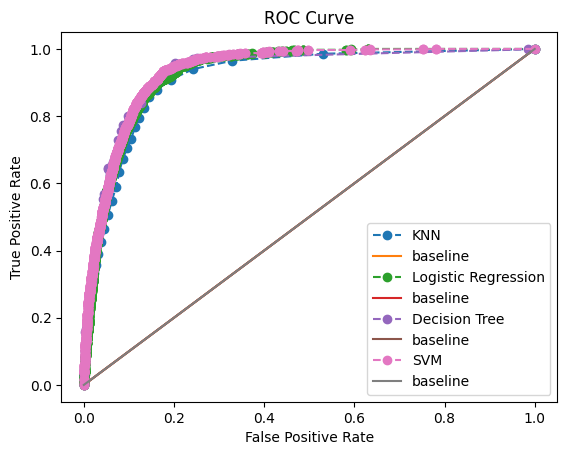

In [103]:
y_models_probs = {
    'KNN':[],
    'Logistic Regression': [],
    'Decision Tree': [],
    'SVM':[]
}

# first scale 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
for model_name, model in finall_models.items():
    model.fit(X_train_scaled, y_train)
    y_models_probs[model_name] = model.predict_proba(X_test_scaled)[:, 1]

for model_name, pred in y_models_probs.items():
    fpr, tpr, thresh_rocs = roc_curve(y_test, pred, pos_label=1)
    # Answer check
    #print('False Positive Rates: ', fpr[:5])
    #print('True Positive Rates: ', tpr[:5])
    plt.plot(fpr, tpr, '--o', label = model_name)
    plt.plot(tpr, tpr, label = 'baseline')
    plt.legend()
    plt.title('ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.grid();

##### Questions